Датасет `wine.csv` містить дані якість вина. Цільовою змінною є `quality`. 


Датасет `wine_predict.csv` не містить значень цільової змінної і призначений для зовнішнього оцінювання.


In [1]:
import sklearn
import xgboost
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import ipywidgets as widgets
import seaborn as sns
sns.set_style("whitegrid")
import warnings
warnings.filterwarnings("ignore")

## Завдання 1

[3 бали] 

Імпортувати датасет `wine.csv` у об'єкт DataFrame і провести попередній аналіз даних засобами pandas, matplotlib, seaborn.   

In [2]:
wine = pd.read_csv("wine.csv")
wine

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.8,0.18,0.31,12.2,0.053,46.0,140.0,0.99800,3.06,0.53,8.9,3
1,7.8,0.18,0.31,12.2,0.053,46.0,140.0,0.99800,3.06,0.53,8.9,3
2,7.3,0.51,0.26,3.3,0.090,7.0,135.0,0.99440,3.01,0.52,8.8,2
3,6.0,0.24,0.27,1.9,0.048,40.0,170.0,0.99380,3.64,0.54,10.0,4
4,5.9,0.62,0.28,3.5,0.039,55.0,152.0,0.99070,3.44,0.44,12.0,3
...,...,...,...,...,...,...,...,...,...,...,...,...
4368,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,3
4369,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,2
4370,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,3
4371,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,4


In [3]:
wine.shape

(4373, 12)

In [4]:
wine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4373 entries, 0 to 4372
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4373 non-null   float64
 1   volatile acidity      4373 non-null   float64
 2   citric acid           4373 non-null   float64
 3   residual sugar        4373 non-null   float64
 4   chlorides             4373 non-null   float64
 5   free sulfur dioxide   4373 non-null   float64
 6   total sulfur dioxide  4373 non-null   float64
 7   density               4373 non-null   float64
 8   pH                    4373 non-null   float64
 9   sulphates             4373 non-null   float64
 10  alcohol               4373 non-null   float64
 11  quality               4373 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 410.1 KB


Отже, маємо 4373 non-null значенняб 11 числових ознак і цільову змінну `quality`. Подивимось на опис кожної ознаки

In [5]:
#Зауваження: Для роботи віджету поле потрібно перезапустити (не загрузиться автоматично при відкритті файлу)
def get_describe(column):
    return wine[column].describe()
widgets.interact(get_describe, column=widgets.Dropdown(options=wine.columns, description="Column:"))

interactive(children=(Dropdown(description='Column:', options=('fixed acidity', 'volatile acidity', 'citric ac…

<function __main__.get_describe(column)>

In [6]:
wine[wine.duplicated()]

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
1,7.8,0.18,0.31,12.2,0.053,46.0,140.0,0.99800,3.06,0.53,8.900000,3
5,6.0,0.24,0.27,1.9,0.048,40.0,170.0,0.99380,3.64,0.54,10.000000,4
17,7.9,0.19,0.26,2.1,0.039,8.0,143.0,0.99420,3.05,0.74,9.800000,2
29,7.4,0.25,0.36,13.2,0.067,53.0,178.0,0.99760,3.01,0.48,9.000000,3
30,7.4,0.25,0.36,13.2,0.067,53.0,178.0,0.99760,3.01,0.48,9.000000,3
...,...,...,...,...,...,...,...,...,...,...,...,...
4303,6.4,0.23,0.35,10.3,0.042,54.0,140.0,0.99670,3.23,0.47,9.200000,2
4325,7.0,0.36,0.35,2.5,0.048,67.0,161.0,0.99146,3.05,0.56,11.100000,3
4326,6.4,0.33,0.44,8.9,0.055,52.0,164.0,0.99488,3.10,0.48,9.600000,2
4331,7.1,0.23,0.39,13.7,0.058,26.0,172.0,0.99755,2.90,0.46,9.000000,3


Бачимо, що маємо 855 об'єктів, які не мають жодного унікального значення ознак. Вони будуть тільки заважати при навчанні, тому видалимо їх.

In [7]:
wine.drop_duplicates(inplace=True)

#### Цільова змінна

Подивимось на розподіл цільової змінної

<AxesSubplot:xlabel='quality', ylabel='count'>

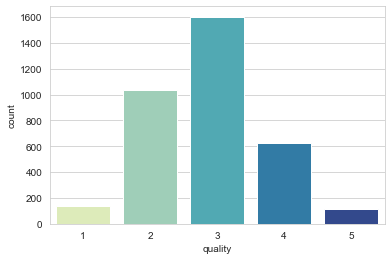

In [8]:
sns.countplot(x='quality',data=wine, palette="YlGnBu")

In [9]:
wine.groupby("quality").apply(lambda df: str(round(df["quality"].count()/wine["quality"].count() * 100, 2)) + "%")

quality
1     3.87%
2    29.45%
3    45.57%
4    17.77%
5     3.35%
dtype: object

Бачимо, що він майже симетричний. Очевидно, присутня незбалансованість класів. Під час навчання моделей будемо ділити дані зі збереженням початкових відношень в класах.

Подивимось на залежність цільової змінної від ознаки `alcohol`

<AxesSubplot:xlabel='quality', ylabel='alcohol'>

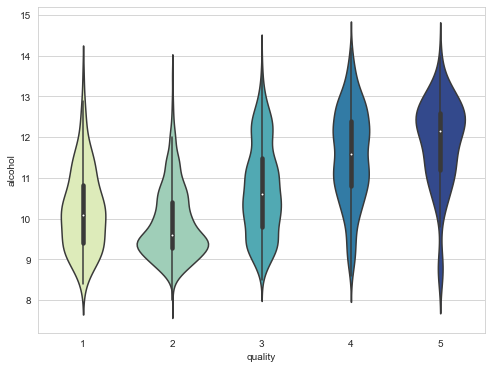

In [10]:
plt.figure(figsize=(8, 6))
sns.violinplot(x="quality", y="alcohol", data=wine, palette="YlGnBu")


Бачимо, що вина кращої якості мають більший вміст алкоголю.

Подивимось також на порівняння `citric acid` i `volatile acidity` з урахуванням якості

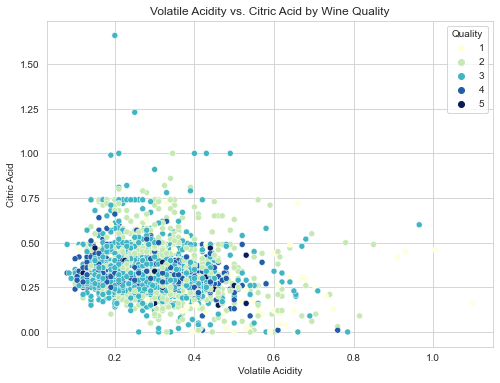

In [11]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=wine, x='volatile acidity', y='citric acid', hue='quality', palette="YlGnBu")
plt.title('Volatile Acidity vs. Citric Acid by Wine Quality')
plt.xlabel('Volatile Acidity')
plt.ylabel('Citric Acid')
plt.legend(title='Quality', loc='upper right')
plt.show()

#### Кореляції

Подивимось на розподіли інших ознак

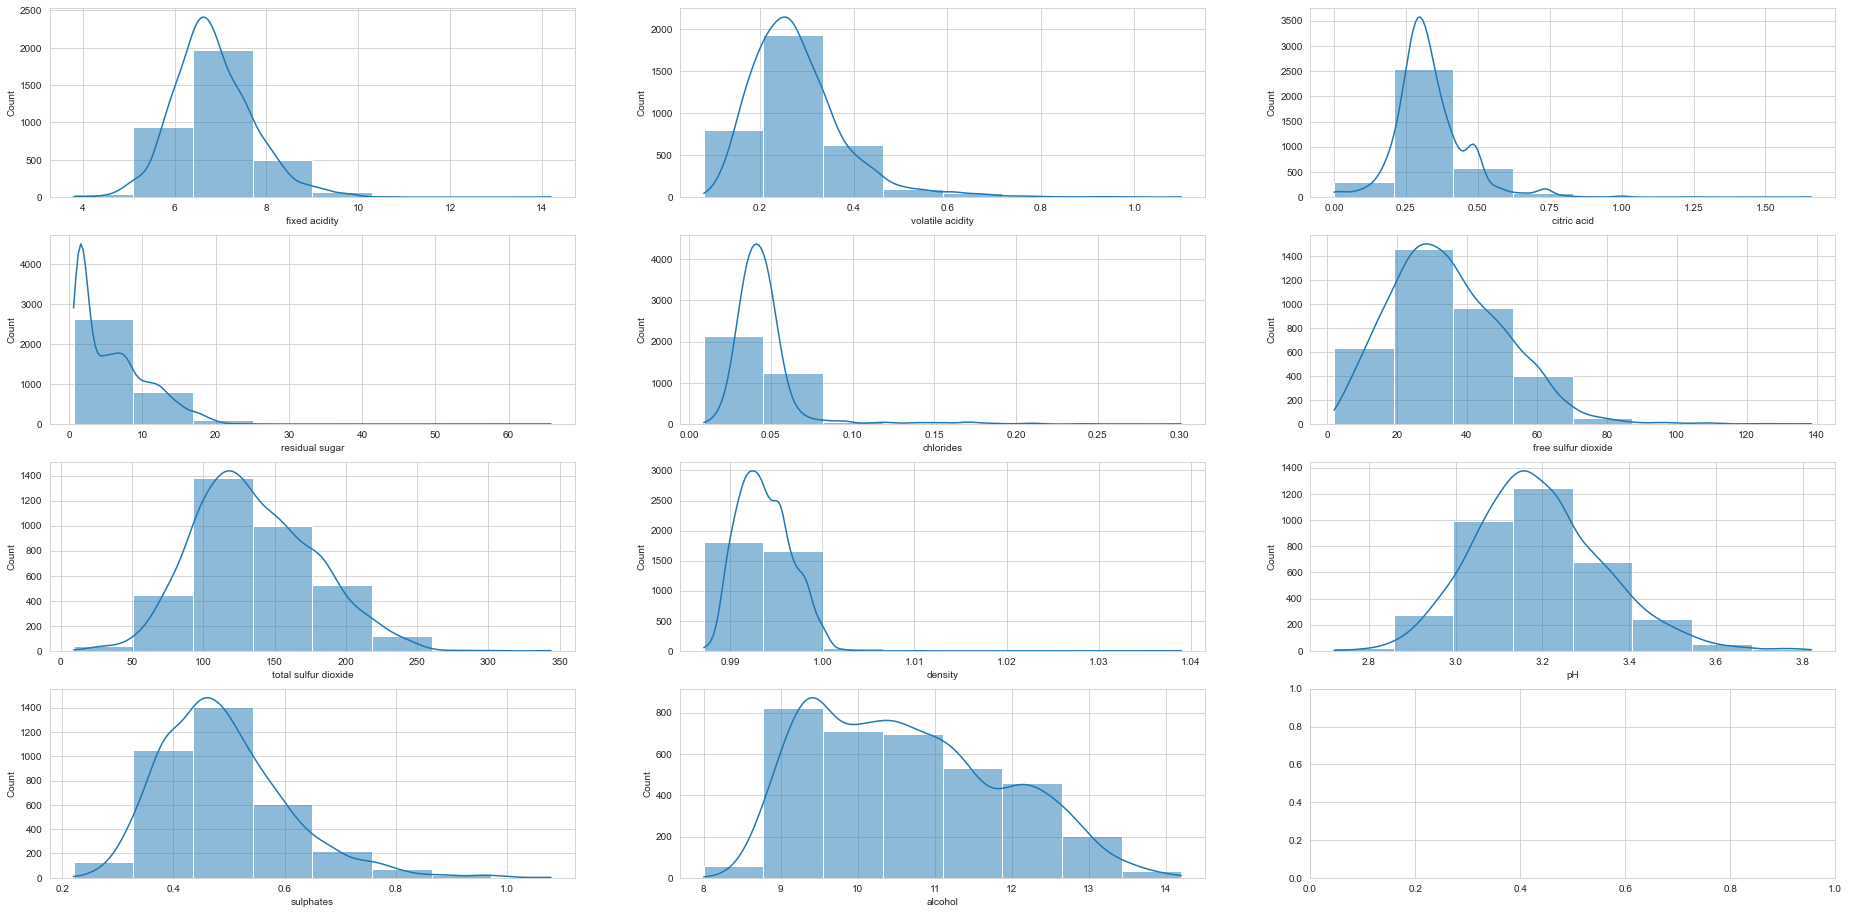

In [12]:
fig, ax = plt.subplots(nrows=4, ncols=3, figsize=(32,16))
for i,col in enumerate(wine.columns[:-1]):
    sns.histplot(x=wine[col],kde=True, bins = 8,  palette="YlGnBu", ax = ax[i // 3][i % 3])

Тепер кореляції між ознаками

<AxesSubplot:>

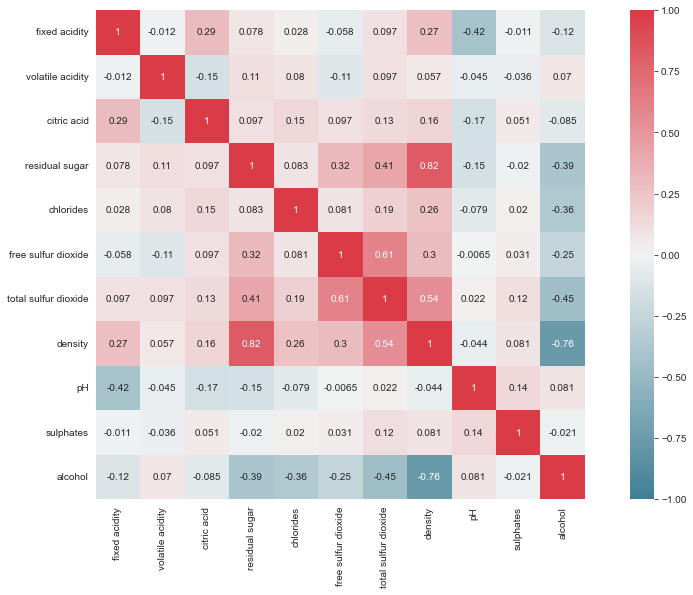

In [13]:
corr = wine.drop(columns=["quality"]).corr()
fig, ax = plt.subplots(figsize=(16, 9))
sns.heatmap(corr, mask=np.zeros_like(corr, dtype=np.bool),vmin=-1, vmax=1,ax=ax,cmap=sns.diverging_palette(220, 10, as_cmap=True), square=True, annot=True)


Бачимо, що дуже залежних ознак немає, крім `density`, яка пов'язана з `residual sugar` i `alcohol`. Потім спробуємо не враховувати її при навчанні.

#### Outliers Handling

На графіках нижче можна побачити, що багато ознак містять певні аномальні значення. Ці викиди можуть негативно впливати на результати наших моделей.

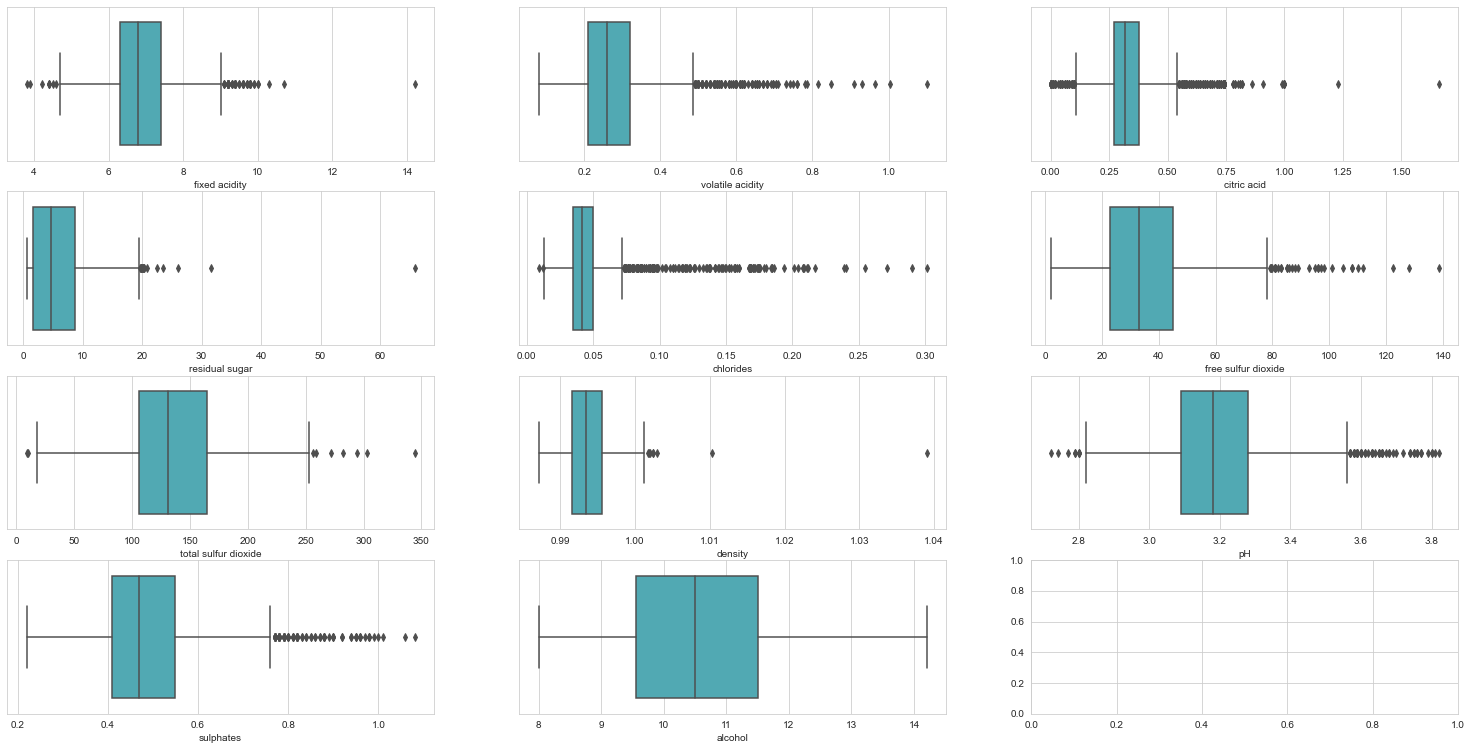

In [14]:
fig, ax = plt.subplots(nrows=4, ncols=3, figsize=(26,13))
for i,col in enumerate(wine.columns[:-1]):
    sns.boxplot(x=wine[col], palette="YlGnBu", ax = ax[i // 3][i % 3])

Спробуємо визначити об'єкти з аномальними значеннями числових ознак і видалити їх. Робити це будемо наступним чином:
* Напишемо функцію, яка в циклі буде проходити по кожній числовій ознаці і визначати викиди
* На кожній ітерації викидом вважатимемо те значення, яке `менше за 1-ий квантиль - крок викиду` або `більше за 3-ій квантиль + крок викиду`
* За крок викиду візьмемо 1,5 * IQR (Interquartile range)
* Для кожної ознаки записуватимемо індекси викидів в список. Після обробки всіх ознак видалятимемо ті рядки, поява яких в списку викидів перевищувала n разів

In [15]:
from collections import Counter
def outliers(df, features, n):
    outliers_ids = []
    for feature in features:
        q1 = np.percentile(df[feature], 25)
        q3 = np.percentile(df[feature], 75)
        step = 1.5*(q3 - q1)
        ids = df[(df[feature] < q1 - step) | (df[feature] > q3 + step)].index
        outliers_ids.extend(ids)
    outliers_ids = Counter(outliers_ids)
    delete = [key for key,value in outliers_ids.items() if value > n]
    return delete
delete = outliers(wine, wine.columns[:-1], 2)
len(delete)

15

## Завдання 2


[12 балів]

### Задача класифікації
   
   * Навчити модель `sklearn.ensemble.VotingClassifier` беручи у якості множини базових алгоритмів { `LogisticRegression`, `SVC`, `KNeighborsClassifier`, `DecisionTreeClassifier` }  та експерементуючи з параметрами базових алгоритмів та композиції. Знайти середню точність (accuracy) для найкращої моделі на відкладеній вибірці.
   
   
   * Навчити модель `sklearn.ensemble.BaggingClassifier` беручи у якості базових алгоритмів `DecisionTreeClassifier` та експерементуючи з параметрами композиції. Знайти середню точність (accuracy) для найкращої моделі на відкладеній вибірці.
   
   
   * Навчити модель `sklearn.ensemble.AdaBoostClassifier` беручи у якості базових алгоритмів `DecisionTreeClassifier` та експерементуючи з параметрами композиції. Знайти середню точність (accuracy) для найкращої моделі на відкладеній вибірці.
   
   
   * Навчити модель `sklearn.ensemble.GradientBoostingClassifier` беручи у якості базових алгоритмів `DecisionTreeClassifier` та експерементуючи з параметрами композиції. Знайти середню точність (accuracy) для найкращої моделі на відкладеній вибірці.
   
   
   * Навчити модель `xgboost.XGBClassifier` беручи у якості базових алгоритмів `gbtree` або `gblinear` або `dart` (розглянути всі варіанти) та експерементуючи з параметрами композиції. Знайти середню точність (accuracy) для найкращої моделі на відкладеній вибірці.
   
   
   * Навчити модель `sklearn.ensemble.StackingClassifier`, беручи у якості множини базових алгоритмів { `LogisticRegression`, `SVC`, `KNeighborsClassifier`, `DecisionTreeClassifier` } а в якості `final_estimator` : `sklearn.linear_model.LogisticRegression` та `sklearn.ensemble.RandomForestClassifier`(розглянути обидва варіанти) та експерементуючи з параметрами базових алгоритмів та композиції. Знайти середню точність (accuracy) для найкращої моделі `StackingClassifier`.



Поділимо дані на навчальну та тестову вибірки

In [16]:
from sklearn.model_selection import train_test_split
def get_original():
    global X, y, X_train, X_test, y_train, y_test
    y = wine["quality"]
    X = wine.drop(columns=["quality"])
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4, stratify = y)
get_original()

Напишемо потрібні функції для зручнішої роботи 

In [17]:
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV
from sklearn.metrics import r2_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from itertools import permutations
from sklearn.model_selection import RepeatedKFold
from sklearn.model_selection import cross_validate
from sklearn.metrics import accuracy_score
def get_best_params(pipeline):
    global X_train, X_test, y_train, y_test
    
    if  type(pipeline[1]) == sklearn.linear_model._logistic.LogisticRegression:
        param_grid = {
            "regression__C": np.logspace(-6, 2, 100),
            "regression__penalty": ["l1","l2", "elasticnet", None],
            "regression__solver": ["lbfgs", "saga"]
        }
        searcher = GridSearchCV(pipeline, [param_grid],
                        scoring="accuracy", cv=5, n_jobs=-1)
        searcher.fit(X_train, y_train)
        best = {name[name.find("__") + 2:]: val for name, val in searcher.best_params_.items()}
        pipeline[1].set_params(**best)
    if  type(pipeline[1]) == sklearn.svm._classes.SVC:
        param_grid = {
            'regression__C' : np.logspace(-3, 3, 50),
            #'regression__kernel' : ['poly',"linear", "rbf"],
        }
        searcher = GridSearchCV(pipeline, [param_grid],
                        scoring="accuracy", cv=5, n_jobs=-1)
        searcher.fit(X_train, y_train)
        best = {name[name.find("__") + 2:]: val for name, val in searcher.best_params_.items()}
        pipeline[1].set_params(**best)
    if  type(pipeline[1]) == sklearn.neighbors._classification.KNeighborsClassifier:
        param_grid = {
            'regression__n_neighbors' : range(3, 40),
            'regression__weights' : ['uniform','distance'],
            'regression__p' : [1,2]
        }
        searcher = GridSearchCV(pipeline, [param_grid],
                        scoring="accuracy", cv=5, n_jobs=-1)
        searcher.fit(X_train, y_train)
        best = {name[name.find("__") + 2:]: val for name, val in searcher.best_params_.items()}
        pipeline[1].set_params(**best)
    if  type(pipeline[1]) == sklearn.tree._classes.DecisionTreeClassifier:
        param_grid = {
            "regression__criterion": ["gini", "entropy", "log_loss"],
            "regression__max_depth" : [None,2, 3,5,7,9,11,12],
            "regression__min_samples_leaf":[1, 2, 3, 5, 10, 20, 30, 40, 50],
            "regression__max_features":["auto", 11 ,"sqrt", "log2", None]           
        }
        searcher = GridSearchCV(pipeline, [param_grid],
                        scoring="accuracy", cv=5, n_jobs=-1)
        searcher.fit(X_train, y_train)
        best = {name[name.find("__") + 2:]: val for name, val in searcher.best_params_.items()}
        pipeline[1].set_params(**best)

        
        
        
def output(pipeline, best_base_params=True, best_params=False, cv=False):
    global X_train, X_test, y_train, y_test
    if best_base_params:
        if type(pipeline[1]) == sklearn.ensemble._voting.VotingClassifier or type(pipeline[1]) == sklearn.ensemble._stacking.StackingClassifier:
            models = [x[1] for x in pipeline[1].estimators]
        else:
            models = [pipeline[1].estimator]
        for model in models:
            inner_pipeline = Pipeline(steps=[
                ('preprocessing', pipeline[0]),
                ('regression', model)
            ])
            get_best_params(inner_pipeline)
    if best_params:
        if type(pipeline[1]) == sklearn.ensemble._voting.VotingClassifier:
            in_weights = [[0.25,0.25,0.25,0.25], [0.3,0.3,0.2,0.2], [0.4,0.2,0.2,0.2], [0.5,0.2,0.2,0.1], [0.3,0.3,0.3,0.1], [0.4,0.4,0.1,0.1], [0.3,0.2,0.25,0.25]]
            weights = []
            for w in in_weights:
                weights.extend(list(set(permutations(w))))
            param_grid = {
                "regression__weights": weights,
                "regression__voting": ["hard", "soft"]
            }
            searcher = GridSearchCV(pipeline, [param_grid],
                            scoring="accuracy", cv=5, n_jobs=-1)
            searcher.fit(X_train, y_train)
            best = {name[name.find("__") + 2:]: val for name, val in searcher.best_params_.items()}
            pipeline[1].set_params(**best)
        if type(pipeline[1]) == sklearn.ensemble._bagging.BaggingClassifier:
            param_grid = {
                "regression__n_estimators": range(2, 30, 2),
                "regression__max_samples": np.arange(0.2, 1.01, 0.2),
                "regression__bootstrap": [True,False],
                "regression__max_features": np.arange(0.2, 1.01, 0.2),
                "regression__bootstrap_features": [True,False]
            }
            searcher = GridSearchCV(pipeline, [param_grid],
                            scoring="accuracy", cv=5, n_jobs=-1)
            searcher.fit(X_train, y_train)
            best = {name[name.find("__") + 2:]: val for name, val in searcher.best_params_.items()}
            pipeline[1].set_params(**best)
        if type(pipeline[1]) == sklearn.ensemble._weight_boosting.AdaBoostClassifier:
            param_grid = {
                "regression__n_estimators": range(2, 150, 10),
                "regression__learning_rate": np.logspace(-3, 2, 25),
                #"regression__algorithm": ['SAMME', 'SAMME.R'],
            }
            searcher = GridSearchCV(pipeline, [param_grid],
                            scoring="accuracy", cv=5, n_jobs=-1)
            searcher.fit(X_train, y_train)
            best = {name[name.find("__") + 2:]: val for name, val in searcher.best_params_.items()}
            pipeline[1].set_params(**best)
        if type(pipeline[1]) == sklearn.ensemble._gb.GradientBoostingClassifier:
            param_grid = {
            "regression__loss": ["log_loss", "exponential"],
            "regression__learning_rate": np.logspace(-3, 2, 25),
            "regression__n_estimators": range(10, 301, 10),
            "regression__criterion": ["squared_error", "friedman_mse"],        
            "regression__max_depth" : [None,3,5,7,9,11,12],
            "regression__min_samples_leaf":[1, 2, 3, 4, 5, 10, 20, 30],
            "regression__max_features":[ 6 ,"sqrt", "log2", None],
            "regression__subsample":np.arange(0.2, 1.01, 0.2)
            }
            searcher = RandomizedSearchCV(pipeline, [param_grid],
                            scoring="accuracy", cv=5, n_jobs=-1, random_state=4, n_iter=100)
            searcher.fit(X_train, y_train)
            best = {name[name.find("__") + 2:]: val for name, val in searcher.best_params_.items()}
            pipeline[1].set_params(**best)
        if type(pipeline[1]) == xgboost.sklearn.XGBClassifier:
            param_grid = {
            "regression__learning_rate": np.logspace(-3, 2, 25),
            "regression__n_estimators": range(10, 301, 10),        
            "regression__max_depth" : [None,3,5,7,9,11,12],
            "regression__booster": ["gbtree"] ,
            "regression__reg_alpha": np.logspace(-3, 2, 25),
            "regression__reg_lambda": np.logspace(-3, 2, 25)
            }
            searcher = RandomizedSearchCV(pipeline, [param_grid],
                            scoring="accuracy", cv=3, n_jobs=-1, random_state=4, n_iter=100)
            searcher.fit(X_train, y_train)
            best = {name[name.find("__") + 2:]: val for name, val in searcher.best_params_.items()}
            pipeline[1].set_params(**best)
        if type(pipeline[1]) == sklearn.ensemble._stacking.StackingClassifier:
            if type(pipeline[1].final_estimator) == sklearn.ensemble._forest.RandomForestClassifier:
                param_grid = {
                    "regression__final_estimator__criterion": ['gini', 'entropy', 'log_loss'],
                    "regression__final_estimator__max_depth" : [None,3,5,7,9,11,12],
                    "regression__final_estimator__min_samples_leaf":[1, 2, 3, 4, 5, 10, 20, 30],
                    "regression__final_estimator__max_features":["sqrt", "log2", None],  
                    "regression__final_estimator__n_estimators": range(10, 200, 10)
                }
                searcher = RandomizedSearchCV(pipeline, [param_grid],
                        scoring="accuracy", cv=3, n_jobs=-1, random_state=4, n_iter=100)
                searcher.fit(X_train, y_train)
                best = {name[name.find("tor") + 5:]: val for name, val in searcher.best_params_.items()}
                pipeline[1].final_estimator.set_params(**best)
            param_grid = {
                "regression__stack_method": ['auto', 'predict_proba', 'decision_function', 'predict'],
                "regression__passthrough": [True, False],        
            }
            searcher = GridSearchCV(pipeline, [param_grid],
                            scoring="accuracy", cv=3, n_jobs=-1)
            searcher.fit(X_train, y_train)
            best = {name[name.find("__") + 2:]: val for name, val in searcher.best_params_.items()}
            pipeline[1].set_params(**best)
                
                
    pipeline.fit(X_train, y_train)
    y_train_pred = pipeline.predict(X_train)
    y_pred = pipeline.predict(X_test)
    print("-"*10 + f"{pipeline[1]}" + "-"*10)
    print(f"Test Accuracy: {round(accuracy_score(y_test, y_pred), 4)}")
    print(f"Train Accuracy: {round(accuracy_score(y_train, y_train_pred), 4)}")
    if cv:
        eval_cv([pipeline], False)
        
def eval_cv(pipelines, title=True):
    global X_train, y_train
    for pipeline in pipelines:
        bagging_cv = cross_validate(pipeline, X_train, y_train, n_jobs=-1,
                    cv=RepeatedKFold(n_splits=10, n_repeats=10), scoring="accuracy")
        if title:
            print(f"{pipeline} -----> {round(bagging_cv['test_score'].mean(),4)}")
        else:
            print(f"CV mean Result: {round(bagging_cv['test_score'].mean(),4)}")        
        
    

### Feature Selection
Для детального підбору найбільш необхідних для навчання ознак потрібно добре розбиратися в сфері самого датасету, а також мати повну інформацію про походження даних і їх збір.

Тому в цьому розділі спробуємо задіяти 2 найбанальніші техніки підбору ознак, з якими отім поексперементуємо при навчанні моделей

#### 1. Прибиремо ознаки, на основі кореляції

Ознака `density` має високу кореляцію з трьома іншими ознаками, тому спробуємо її видалити

In [18]:
features = X_train.columns
low_corr = features.drop(["density"])

#### 2. Спробуємо скористатись `SequentialFeatureSelector` для підбору важливих ознак

In [19]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

column_transformer = ColumnTransformer([
    ("passthrough", StandardScaler(), low_corr),
])

for model in [LogisticRegression(), SVC(), KNeighborsClassifier(), DecisionTreeClassifier()]:
    pipeline = Pipeline(steps=[
        ('preprocessing', column_transformer),
        ('regression', model)
    ]) 
    get_best_params(pipeline)
    sfs = SequentialFeatureSelector(model, n_jobs = -1, n_features_to_select = 7, direction="forward")
    sfs.fit(column_transformer.fit_transform(X_train[low_corr]), y_train)
    lin_selected = low_corr[sfs.get_support()]
    print(lin_selected)

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'pH', 'sulphates', 'alcohol'],
      dtype='object')
Index(['fixed acidity', 'volatile acidity', 'residual sugar', 'chlorides',
       'free sulfur dioxide', 'total sulfur dioxide', 'alcohol'],
      dtype='object')
Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'pH', 'alcohol'],
      dtype='object')
Index(['volatile acidity', 'citric acid', 'residual sugar', 'chlorides',
       'total sulfur dioxide', 'sulphates', 'alcohol'],
      dtype='object')


Виберемо ті, які зустрічаються найчастіше

In [20]:
lin_selected = [, 'fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'free sulfur dioxide','chlorides', 'alcohol', 'pH']

### Voting Classifier

Розглянемо результати `VotingClassifier`, поставивши за базові алгоритми `LogisticRegression`, `SVC`, `KNeighborsClassifier` і `DecisionTreeClassifier`.

In [21]:
from sklearn.ensemble import VotingClassifier
estimators = [
    ("logreg",LogisticRegression()), 
    ("svc", SVC()), 
    ("knn", KNeighborsClassifier()), 
    ("dtc", DecisionTreeClassifier(random_state=4))
                ] 

column_transformer = ColumnTransformer([
    ("passthrough", "passthrough", features),
])
pipeline = Pipeline(steps=[
    ('preprocessing', column_transformer),
    ('regression', VotingClassifier(estimators, n_jobs=-1))
]) 


output(pipeline, best_base_params=False, cv=True)

----------VotingClassifier(estimators=[('logreg', LogisticRegression()), ('svc', SVC()),
                             ('knn', KNeighborsClassifier()),
                             ('dtc', DecisionTreeClassifier(random_state=4))],
                 n_jobs=-1)----------
Test Accuracy: 0.5014
Train Accuracy: 0.6496
CV mean Result: 0.4957


Додамо скейлинг до даних і спробуємо використати відібрані нами `lin_selected` ознаки

In [22]:
column_transformer = ColumnTransformer([
    ("scaler", StandardScaler(), lin_selected),
])
pipeline = Pipeline(steps=[
    ('preprocessing', column_transformer),
    ('regression', VotingClassifier(estimators, n_jobs=-1))
]) 
output(pipeline, best_base_params=False, cv=True)

----------VotingClassifier(estimators=[('logreg', LogisticRegression()), ('svc', SVC()),
                             ('knn', KNeighborsClassifier()),
                             ('dtc', DecisionTreeClassifier(random_state=4))],
                 n_jobs=-1)----------
Test Accuracy: 0.5469
Train Accuracy: 0.6986
CV mean Result: 0.5546


Бачимо, що результати покращились як на тестовій вибірці, так і при крос-валідації

Пдберемо найкращі параметри для базових моделей.

In [23]:
output(pipeline, cv=True)

----------VotingClassifier(estimators=[('logreg',
                              LogisticRegression(C=0.31257158496882415,
                                                 penalty='l1', solver='saga')),
                             ('svc', SVC(C=0.655128556859551)),
                             ('knn',
                              KNeighborsClassifier(n_neighbors=30, p=1,
                                                   weights='distance')),
                             ('dtc',
                              DecisionTreeClassifier(max_depth=5,
                                                     max_features=11,
                                                     min_samples_leaf=30,
                                                     random_state=4))],
                 n_jobs=-1)----------
Test Accuracy: 0.5582
Train Accuracy: 0.6421
CV mean Result: 0.5619


Результати незначно покращились. Спробуємо використати бінаризацію і `PolinomialFeatures` 

In [24]:
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.preprocessing import PolynomialFeatures

column_transformer_bin = ColumnTransformer([
    ("scaler", StandardScaler(), lin_selected),
    ('binner', KBinsDiscretizer(n_bins=6, strategy='quantile'), lin_selected),
])
pipeline_bin = Pipeline(steps=[
    ('preprocessing', column_transformer_bin),
    ('regression', VotingClassifier(estimators, n_jobs=-1))
]) 
output(pipeline_bin, cv=True)

----------VotingClassifier(estimators=[('logreg',
                              LogisticRegression(C=0.04037017258596558)),
                             ('svc', SVC(C=0.49417133613238334)),
                             ('knn',
                              KNeighborsClassifier(n_neighbors=36,
                                                   weights='distance')),
                             ('dtc',
                              DecisionTreeClassifier(max_depth=5,
                                                     min_samples_leaf=30,
                                                     random_state=4))],
                 n_jobs=-1)----------
Test Accuracy: 0.5554
Train Accuracy: 0.6457
CV mean Result: 0.5622


Бачимо, що реузльтати майже не змінилися. Продовжимо використовувати тільки скейлинг задля швидшого підбору паарметрів.

Поексперементуємо з вагами кожної базової моделі. Поставимо більші ваги складнішим моделям.

In [25]:
pipeline[1].set_params(weights=[0.2, 0.2, 0.2, 0.4])
output(pipeline, cv=True)

----------VotingClassifier(estimators=[('logreg',
                              LogisticRegression(C=0.31257158496882415,
                                                 penalty='l1', solver='saga')),
                             ('svc', SVC(C=0.655128556859551)),
                             ('knn',
                              KNeighborsClassifier(n_neighbors=30, p=1,
                                                   weights='distance')),
                             ('dtc',
                              DecisionTreeClassifier(max_depth=5,
                                                     max_features=11,
                                                     min_samples_leaf=30,
                                                     random_state=4))],
                 n_jobs=-1, weights=[0.2, 0.2, 0.2, 0.4])----------
Test Accuracy: 0.5483
Train Accuracy: 0.6404
CV mean Result: 0.5637


Це трішки погіршило рзультати. Спробуємо підібрати ваги і інші параметри для ансамблю вцілому.

In [26]:
output(pipeline, best_params=True, cv=True)

----------VotingClassifier(estimators=[('logreg',
                              LogisticRegression(C=0.31257158496882415,
                                                 penalty='l1', solver='saga')),
                             ('svc', SVC(C=0.655128556859551)),
                             ('knn',
                              KNeighborsClassifier(n_neighbors=30, p=1,
                                                   weights='distance')),
                             ('dtc',
                              DecisionTreeClassifier(max_depth=5,
                                                     max_features=11,
                                                     min_samples_leaf=30,
                                                     random_state=4))],
                 n_jobs=-1, weights=(0.3, 0.3, 0.1, 0.3))----------
Test Accuracy: 0.5568
Train Accuracy: 0.5906
CV mean Result: 0.5659


Результати незначно покращились як на тесті, так і при крос-валідації

Спробуємо також видалити об'єкти, які ми визначили в аналізі як викиди.

In [27]:
delete = outliers(wine, lin_selected, 2)
X.drop(delete, inplace=True)
y.drop(delete, inplace=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4, stratify=y)
output(pipeline, best_params=True, cv=True)

----------VotingClassifier(estimators=[('logreg',
                              LogisticRegression(C=0.25950242113997374,
                                                 penalty='l1', solver='saga')),
                             ('svc', SVC(C=1.5264179671752334)),
                             ('knn',
                              KNeighborsClassifier(n_neighbors=19,
                                                   weights='distance')),
                             ('dtc',
                              DecisionTreeClassifier(max_depth=3,
                                                     max_features=11,
                                                     min_samples_leaf=50,
                                                     random_state=4))],
                 n_jobs=-1, weights=(0.3, 0.3, 0.3, 0.1))----------
Test Accuracy: 0.567
Train Accuracy: 0.6569
CV mean Result: 0.5662


Бачимо, що результат на тестовій вибірці покращився, але крос-валідація показує незначно гірші результати.

Наостанок порівняємо результати базових моделей з результатами ансамблю для найкращого ансамблю.

Val :: скори для окремих алгоритмів: 
   {'logreg': 0.5511630655821047, 'svc': 0.5623812913065581, 'knn': 0.5564697508896796, 'dtc': 0.540902389425521}
Val :: середнє скорів окремих алгоритмів:  0.5527291243009659
Val :: скор ансамблю :  0.5660104219623793 



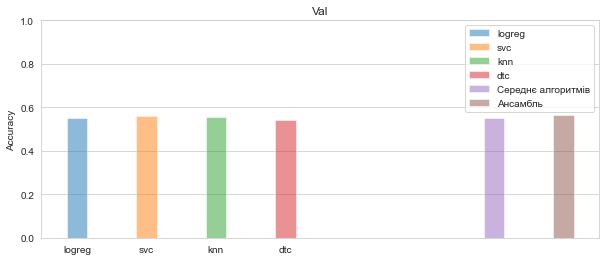

In [28]:
from sklearn.model_selection import RepeatedStratifiedKFold
def compare(pipeline):
    global estimators
    base_scores= {est[0]: [] for est in pipeline[1].estimators}
    for estimator in estimators:
        inner_pipeline = Pipeline(steps=[
            ('preprocessing', pipeline[0]),
            ('regression', estimator[1])
        ])

        clf_boost_cv = cross_validate(inner_pipeline, X_train, y_train, n_jobs=-1,
                            cv=RepeatedStratifiedKFold(n_splits=10, n_repeats=10))
        base_scores[estimator[0]] = clf_boost_cv['test_score'].mean()
        boost_cv = cross_validate(pipeline, X_train, y_train, n_jobs=-1,
                                cv=RepeatedStratifiedKFold(n_splits=10, n_repeats=10))   
    print('Val :: скори для окремих алгоритмів: \n  ', base_scores)
    # усереднене значення скорів окремих алгоритмів
    print('Val :: середнє скорів окремих алгоритмів: ', np.mean([v for k, v in base_scores.items()]))
    # середній скор ансамблю після всіх проходів 
    print('Val :: скор ансамблю : ', boost_cv['test_score'].mean(), '\n')

    
    # візуалізуємо
    fig = plt.figure(figsize=(10,4))
    #  скори окремих алгоритмів
    for i, (k, v) in enumerate(base_scores.items()):
        plt.bar(x=i, height=v, align='center', width=0.3, alpha=0.5, label=k)

    # середнє скорів окремих алгоритмів
    plt.bar(
        x=len(pipeline[1].estimators)+2, 
        height=np.mean([v for k, v in base_scores.items()]), 
        align='center', width=0.3, alpha=0.5, label="Середнє алгоритмів"
    )
    # скор ансамблю
    plt.bar(
        x=len(pipeline[1].estimators)+3, 
        height=boost_cv['test_score'].mean(), 
        align='center', width=0.3, alpha=0.5, label="Ансамбль"
    )
    plt.xticks(np.arange(4), base_scores.keys())
    plt.title('Val')
    plt.ylabel('Accuracy')
    plt.ylim((0,1))
    plt.grid(axis='x')
    plt.legend(loc='best')
    plt.show()
    

compare(pipeline)

Бачимо, що ансамбль дає кращі результатиб ніж найкращі окремі моделі.

Також можемо подивитись на просту оцінку різноманітності базових алгоритмів у ансамблі.

In [29]:
def disagreement(est1, est2):
    n = len(est1)
    count = 0
    for i, j in zip(est1,est2):
        if i != j:
            count += 1
    return count/n

def eval_disagr(ens, test_set):
    preds = []
    for est in ens[1].estimators_:
        preds.append(est.predict(test_set))
    
    disagr_ens = []
    for est1 in preds:
        for est2 in preds:
            disagr_ens.append(disagreement(est1, est2))
        
    return np.array(disagr_ens).reshape(len(preds), -1)

In [30]:
disagr_ens_hv = eval_disagr(pipeline, column_transformer.fit_transform(X_test))

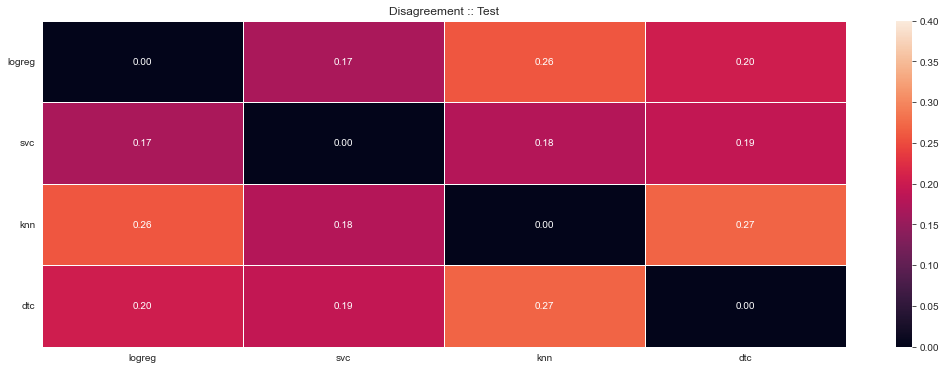

In [31]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(18,6))
sns.heatmap(disagr_ens_hv, annot=True, fmt='0.2f', linewidths=0.5, vmin=0, vmax=0.4, ax=ax)
ax.set_title('Disagreement :: Test')
plt.xticks(np.arange(4)+0.5, pipeline[1].named_estimators_)
plt.yticks(np.arange(4)+0.5, pipeline[1].named_estimators_, rotation=0)
plt.show()
get_original()

Бачимо, що наші базові алгоритми мають доволі високу узгодженість, але все ж не є повністю нерізноманітними.

##### Висновок

 Найкращим ансамблем виявився `VotingClassifier` з скейлингом, підібраними найкращими параметрами для базових моделей і ансамблю вцілому, навчений на ознаках `lin_selected` з викинутими `outliers` і поділом на виібрки за допомогою `stratify`

### Bagging Classifier

In [32]:
from sklearn.ensemble import BaggingClassifier
column_transformer = ColumnTransformer([
    ("passthrough", "passthrough", features),
])
pipeline = Pipeline(steps=[
    ('preprocessing', column_transformer),
    ('regression', BaggingClassifier(DecisionTreeClassifier(random_state=4), random_state=5, n_jobs=-1))
]) 
output(pipeline, best_base_params=False, cv=True)

----------BaggingClassifier(estimator=DecisionTreeClassifier(random_state=4), n_jobs=-1,
                  random_state=5)----------
Test Accuracy: 0.5085
Train Accuracy: 0.9797
CV mean Result: 0.5351


Бачимо, що присутнє значне перенавчання (через непідібрану глибину дерев). Підберемо найкращі параметри для дерев і додамо скейлинг.

In [33]:
from sklearn.ensemble import BaggingClassifier
column_transformer = ColumnTransformer([
    ("scaler", StandardScaler(), lin_selected),
])
pipeline = Pipeline(steps=[
    ('preprocessing', column_transformer),
    ('regression', BaggingClassifier(DecisionTreeClassifier(random_state=4), random_state=5, n_jobs=-1))
]) 
output(pipeline, cv=True)

----------BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=5, max_features=11,
                                                   min_samples_leaf=30,
                                                   random_state=4),
                  n_jobs=-1, random_state=5)----------
Test Accuracy: 0.5327
Train Accuracy: 0.5824
CV mean Result: 0.5486


Бачимо, що перенавчання зникло. Спробуємо додати бінаризацію.

In [34]:
pipeline_bin = Pipeline(steps=[
    ('preprocessing', column_transformer_bin),
    ('regression', BaggingClassifier(DecisionTreeClassifier(random_state=4), random_state=5, n_jobs=-1))
]) 
output(pipeline_bin, cv=True)

----------BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=5,
                                                   min_samples_leaf=30,
                                                   random_state=4),
                  n_jobs=-1, random_state=5)----------
Test Accuracy: 0.5412
Train Accuracy: 0.5853
CV mean Result: 0.5478


Бачимо, що результати на тестовій вибірці покращились, але при крос-валідації майже не змінились.

Підберемо також параметри для самого ансамблю.

In [35]:
output(pipeline_bin,best_params=True, cv=True)

----------BaggingClassifier(bootstrap=False, bootstrap_features=True,
                  estimator=DecisionTreeClassifier(max_depth=5,
                                                   min_samples_leaf=30,
                                                   random_state=4),
                  n_estimators=8, n_jobs=-1, random_state=5)----------
Test Accuracy: 0.5312
Train Accuracy: 0.5824
CV mean Result: 0.5463


Результати це фактично не змінює.

Спробуємо викинути об'єкти, які ми вважаємо outliers.

In [36]:
delete = outliers(wine, lin_selected, 2)
X.drop(delete, inplace=True)
y.drop(delete, inplace=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4, stratify=y)
output(pipeline_bin, best_params=True, cv=True)

----------BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=3,
                                                   min_samples_leaf=50,
                                                   random_state=4),
                  max_features=0.4, max_samples=0.8, n_estimators=16, n_jobs=-1,
                  random_state=5)----------
Test Accuracy: 0.5427
Train Accuracy: 0.5572
CV mean Result: 0.5387


Це незначно погіршило результати. Повернемо ці об'єкти назад.

In [37]:
get_original()

Порівняємо роботу базового алгоритму і ансамблю.

In [38]:
output(pipeline_bin,best_params=True, cv=True)
from sklearn.model_selection import RepeatedStratifiedKFold
inner_pipeline = Pipeline(steps=[
    ('preprocessing', pipeline_bin[0]),
    ('regression', pipeline_bin[1].estimator)
])

clf_bag_cv = cross_validate(inner_pipeline, X_train, y_train, n_jobs=-1,
                        cv=RepeatedStratifiedKFold(n_splits=10, n_repeats=10))
bag_cv = cross_validate(pipeline_bin, X_train, y_train, n_jobs=-1,
                                cv=RepeatedStratifiedKFold(n_splits=10, n_repeats=10))
    
print("Mean for base model: ",clf_bag_cv['test_score'].mean())
print("Mean for bagging: ", bag_cv['test_score'].mean())

----------BaggingClassifier(bootstrap=False, bootstrap_features=True,
                  estimator=DecisionTreeClassifier(max_depth=5,
                                                   min_samples_leaf=30,
                                                   random_state=4),
                  n_estimators=8, n_jobs=-1, random_state=5)----------
Test Accuracy: 0.5312
Train Accuracy: 0.5824
CV mean Result: 0.5465
Mean for base model:  0.5315533429242069
Mean for bagging:  0.5489451301077711


Бачимо, що як і для попереднього ансамблю, результат ансамблю кращий за результат базової моделі

Подивимось, заради цікавості, на результат ансамблю в залежності від кількості базових моделей.

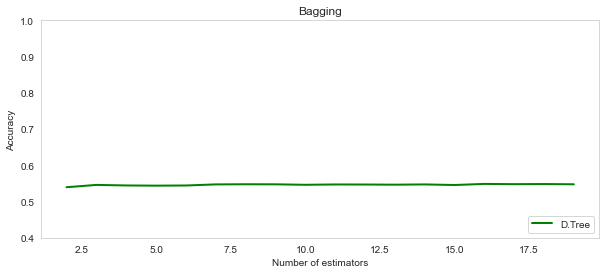

In [39]:
n_est_dict = {}
for n_est in range(2,20): 
    pipeline_bin[1].set_params(n_estimators=n_est)
    bagging_cv = cross_validate(pipeline_bin, X_train, y_train, n_jobs=-1,
                            cv=RepeatedStratifiedKFold(n_splits=10, n_repeats=10)) 
    n_est_dict[n_est]=bagging_cv['test_score'].mean()

fig = plt.figure(figsize=(10,4))

ne_bag, dtree_bag_scores = n_est_dict.keys(), n_est_dict.values()
plt.plot(ne_bag, dtree_bag_scores, lw=2, color='g', label='D.Tree')

plt.xlabel("Number of estimators")
plt.ylabel("Accuracy")
plt.ylim([0.4,1])
plt.legend(loc = 'lower right')
plt.grid()
plt.title('Bagging')
fig.savefig('bag-est-plot.pdf')

Бачимо, що у нашому випадку на наших даних результат майже не змінюється.

Подивимось на оцінку різноманітності базових алгоритмів

In [40]:
disagr_bag_dtree = eval_disagr(pipeline_bin, column_transformer_bin.fit_transform(X_test))

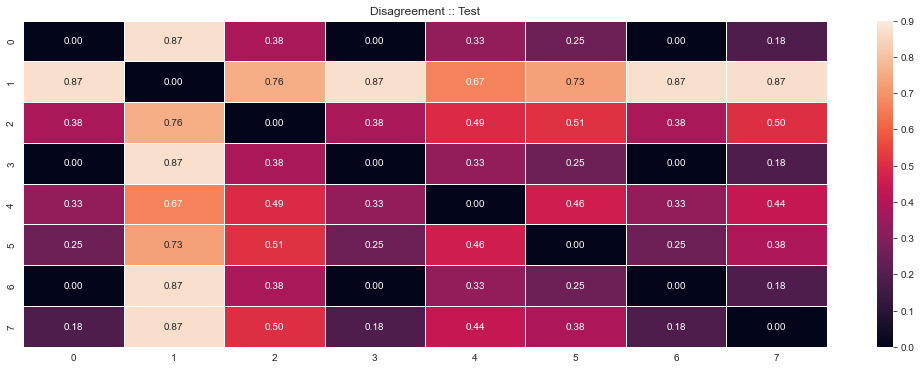

In [41]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(18,6))
sns.heatmap(disagr_bag_dtree, annot=True, fmt='0.2f', linewidths=0.5, vmin=0, vmax=0.9, ax=ax)
ax.set_title('Disagreement :: Test')
plt.show()

Бачимо, що результати тут значно менш узгоджені, але є різні базові моделі, які узгоджуються повністю.

##### Висновок.

Найкращою моделлю виявився `BaggingClassifier` з скейлингом, бінаризацією, з підібраними найкращими гіперпараметрами для базового алгоритму і ансамблю вцілому, натренований на ознаках `lin_selected` з використанням `stratify`

###  AdaBoostClassifier

In [42]:
from sklearn.ensemble import AdaBoostClassifier
column_transformer = ColumnTransformer([
    ("passthrough", "passthrough", features),
])
pipeline = Pipeline(steps=[
    ('preprocessing', column_transformer),
    ('regression', AdaBoostClassifier(DecisionTreeClassifier(random_state=4), random_state=5))
]) 
output(pipeline, best_base_params=False, cv=True) 

----------AdaBoostClassifier(estimator=DecisionTreeClassifier(random_state=4),
                   random_state=5)----------
Test Accuracy: 0.4162
Train Accuracy: 1.0
CV mean Result: 0.4544


Бачимо, що результати гірші і присутнє перенавчання. Спробуємо підібрати параметри для дерев і додати скейлинг.

In [43]:
from sklearn.ensemble import AdaBoostClassifier
column_transformer = ColumnTransformer([
    ("scaler", StandardScaler(), features),
])
pipeline = Pipeline(steps=[
    ('preprocessing', column_transformer),
    ('regression', AdaBoostClassifier(DecisionTreeClassifier(random_state=4), random_state=5))
]) 
output(pipeline, cv=True) 

----------AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=5,
                                                    max_features=11,
                                                    min_samples_leaf=20,
                                                    random_state=4),
                   random_state=5)----------
Test Accuracy: 0.4688
Train Accuracy: 0.6155
CV mean Result: 0.4826


Результати покращились, а перенавчання зменшилось. Додамо бінаризацію.

In [44]:
column_transformer_bin = ColumnTransformer([
    ("scaler", StandardScaler(), features),
    ('binner', KBinsDiscretizer(n_bins=6, strategy='quantile'), lin_selected),
])
pipeline_bin = Pipeline(steps=[
    ('preprocessing', column_transformer_bin),
    ('regression', AdaBoostClassifier(DecisionTreeClassifier(random_state=4), random_state=5))
]) 
output(pipeline_bin, cv=True)

----------AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=5,
                                                    min_samples_leaf=20,
                                                    random_state=4),
                   random_state=5)----------
Test Accuracy: 0.4702
Train Accuracy: 0.6052
CV mean Result: 0.4889


Результати майже не змінились. Спробуємо підібрати найкращі паарметри для бустера вцілому і порівняти ще раз

In [45]:
output(pipeline, best_params=True, cv=True)
output(pipeline_bin, best_params=True, cv=True)

----------AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=5,
                                                    max_features=11,
                                                    min_samples_leaf=20,
                                                    random_state=4),
                   learning_rate=0.046415888336127795, n_estimators=2,
                   random_state=5)----------
Test Accuracy: 0.5099
Train Accuracy: 0.5864
CV mean Result: 0.5364
----------AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=5,
                                                    min_samples_leaf=20,
                                                    random_state=4),
                   learning_rate=0.046415888336127795, n_estimators=2,
                   random_state=5)----------
Test Accuracy: 0.5099
Train Accuracy: 0.5864
CV mean Result: 0.537


Бачимо, що результати майже ідентичні, тому задля швидкості підбору параметрів користуватимемось моделлю без бінаризації.

Приберемо об'єкти, які вважаємо викидами.

In [46]:
delete = outliers(wine, lin_selected, 2)
X.drop(delete, inplace=True)
y.drop(delete, inplace=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4, stratify=y)
output(pipeline, best_params=True, cv=True)

----------AdaBoostClassifier(estimator=DecisionTreeClassifier(criterion='entropy',
                                                    max_depth=7,
                                                    max_features=11,
                                                    min_samples_leaf=40,
                                                    random_state=4),
                   learning_rate=0.004216965034285823, n_estimators=102,
                   random_state=5)----------
Test Accuracy: 0.547
Train Accuracy: 0.5857
CV mean Result: 0.5461


Це покращило результати. Порівняємо роботу бустера і базового алгоритму.

In [47]:
inner_pipeline = Pipeline(steps=[
    ('preprocessing', pipeline[0]),
    ('regression', pipeline[1].estimator)
])

clf_boost_cv = cross_validate(inner_pipeline, X_train, y_train, n_jobs=-1,
                        cv=RepeatedStratifiedKFold(n_splits=10, n_repeats=10))
boost_cv = cross_validate(pipeline, X_train, y_train, n_jobs=-1,
                                cv=RepeatedStratifiedKFold(n_splits=10, n_repeats=10))
    
print("Mean for base model: ",clf_boost_cv['test_score'].mean())
print("Mean for boost: ", boost_cv['test_score'].mean())

Mean for base model:  0.5192391967463141
Mean for boost:  0.5471623029994916


Бачимо, що результати знову кращі.

Подивимось також на залежність від довжини композиції

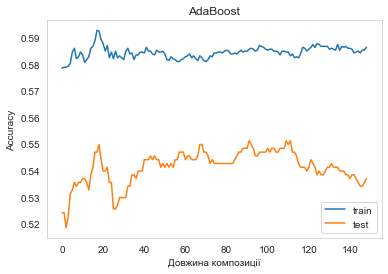

In [48]:
scores_tr = []
scores_ts = []
for n_est in range(1, 150):
    pipeline[1].set_params(n_estimators=n_est)
    pipeline.fit(X_train, y_train)
    scores_tr.append(pipeline.score(X_train, y_train))
    scores_ts.append(pipeline.score(X_test, y_test))
    
plt.plot(scores_tr, label='train')
plt.plot(scores_ts, label='test')
plt.xlabel('Довжина композиції')
plt.ylabel('Accuracy')
plt.title('AdaBoost')
plt.legend()
plt.grid()
get_original()

##### Висновок.

Отже, найкращою моделлю стала AdaBoostRegressor з скейлингом і підібраними найкращими параметрами для базовової моделі і бусту вцілому, з викинутими outliers і з stratify.

###  GradientBoostClassifier

In [49]:
from sklearn.ensemble import GradientBoostingClassifier
column_transformer = ColumnTransformer([
    ("passthrough", "passthrough", features),
])
pipeline = Pipeline(steps=[
    ('preprocessing', column_transformer),
    ('regression', GradientBoostingClassifier())
]) 
output(pipeline, best_base_params=False, cv=True) 

----------GradientBoostingClassifier()----------
Test Accuracy: 0.5526
Train Accuracy: 0.7367
CV mean Result: 0.5569


Бачимо, що результати зразу одні з найкращих. Додамо скейлинг і поексперементуємо з бінаризацією і ознаками `lin_selected`

In [50]:
column_transformer_bin = ColumnTransformer([
    ("scaler", StandardScaler(), features),
    ('binner', KBinsDiscretizer(n_bins=6, strategy='quantile'), features),
])
pipeline_bin = Pipeline(steps=[
    ('preprocessing', column_transformer_bin),
    ('regression', GradientBoostingClassifier())
]) 
output(pipeline, best_base_params=False, cv=True) 

----------GradientBoostingClassifier()----------
Test Accuracy: 0.5511
Train Accuracy: 0.7367
CV mean Result: 0.5585


Результати майже не змінились. Підберемо параметри для бустера. 

In [51]:
output(pipeline_bin, best_base_params=False,best_params=True, cv=True)

----------GradientBoostingClassifier(criterion='squared_error',
                           learning_rate=0.011006941712522098, max_depth=None,
                           max_features=6, min_samples_leaf=4, n_estimators=210,
                           subsample=0.6000000000000001)----------
Test Accuracy: 0.5653
Train Accuracy: 0.9982
CV mean Result: 0.575


Бачимо, що з'явилось перенавчання, але результати на тестовій вибірці і при крос-валідації значно покращились.


Спробуємо задати дерево з оптимальними параметрами, як модель для початкових передбачень в `init`.

In [52]:
inner_pipeline = Pipeline(steps=[
    ('preprocessing', pipeline_bin[0]),
    ('regression', DecisionTreeClassifier(random_state=4))
])
get_best_params(inner_pipeline)
pipeline_bin[1].set_params(init=inner_pipeline[1])
output(pipeline_bin, best_base_params=False, cv=True)

----------GradientBoostingClassifier(criterion='squared_error',
                           init=DecisionTreeClassifier(max_depth=5,
                                                       min_samples_leaf=20,
                                                       random_state=4),
                           learning_rate=0.011006941712522098, max_depth=None,
                           max_features=6, min_samples_leaf=4, n_estimators=210,
                           subsample=0.6000000000000001)----------
Test Accuracy: 0.5526
Train Accuracy: 0.9982
CV mean Result: 0.5612


Це погіршило результати. Тому заберемо `init` і викинемо outliers.

In [53]:
pipeline_bin[1].set_params(init=None)
delete = outliers(wine, lin_selected, 2)
X.drop(delete, inplace=True)
y.drop(delete, inplace=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4, stratify=y)
output(pipeline_bin, best_params=True, best_base_params=False, cv=True)

----------GradientBoostingClassifier(criterion='squared_error',
                           learning_rate=0.011006941712522098, max_depth=None,
                           max_features=6, min_samples_leaf=4, n_estimators=210,
                           subsample=0.6000000000000001)----------
Test Accuracy: 0.5741
Train Accuracy: 0.9968
CV mean Result: 0.565


Результати на крос-валідації незначно погіршились. Тому повернемо попередні дані.

In [54]:
get_original()
output(pipeline_bin, best_base_params=False,best_params=True, cv=True)

----------GradientBoostingClassifier(criterion='squared_error',
                           learning_rate=0.028729848333536655, max_depth=None,
                           max_features='sqrt', min_samples_leaf=5,
                           n_estimators=260, subsample=0.8)----------
Test Accuracy: 0.5597
Train Accuracy: 1.0
CV mean Result: 0.5699


##### Висновок.

Загалом найкращою моделлю стала `GradientBoostingClassifier` зі скейлингом, бінаризацією, підбором найкращих параметрів, навчена на всіх ознаках з `stratify`

###  XGBClassifier

In [55]:
import xgboost
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.fit_transform(y_test)
column_transformer = ColumnTransformer([
    ("passthrough", "passthrough", features),
])
pipeline = Pipeline(steps=[
    ('preprocessing', column_transformer),
    ('regression', xgboost.XGBClassifier(n_jobs=-1, ))
]) 
output(pipeline, best_base_params=False, cv=True) 

----------XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=-1,
              num_parallel_tree=None, objective='multi:softprob', ...)----------
Test Accuracy: 0.5384
Train Accuracy: 0.9993
CV mean Result: 0.5561


Бачимо, що результати непогані, але присутнє перенавчання. Спробуємо додати скейлинг і бінаризацію.

In [56]:
pipeline_bin = Pipeline(steps=[
    ('preprocessing', column_transformer_bin),
    ('regression', xgboost.XGBClassifier(n_jobs=-1, ))
]) 
output(pipeline_bin, best_base_params=False, cv=True) 

----------XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=-1,
              num_parallel_tree=None, objective='multi:softprob', ...)----------
Test Accuracy: 0.5455
Train Accuracy: 1.0
CV mean Result: 0.5518


Бачимо, що результати майже не змінились. Підберемо параметри для бусту, щоб зменшити перенавчання.

In [57]:
output(pipeline_bin, best_base_params=False,best_params=True, cv=True) 

----------XGBClassifier(base_score=None, booster='gbtree', callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.07498942093324558,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=-1,
              num_parallel_tree=None, objective='multi:softprob', ...)----------
Test Accuracy: 0.5526
Train Accuracy: 0.6532
CV mean Result: 0.5622


Результати покращились і зменшилось перенавчання

Видалимо outliers і подивимось на результат

In [58]:
delete = outliers(X, features, 1)
X.drop(delete, inplace=True)
y.drop(delete, inplace=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4)
y_train = le.fit_transform(y_train)
y_test = le.fit_transform(y_test)
output(pipeline_bin, best_base_params=False,best_params=True, cv=True)
get_original()
y_train = le.fit_transform(y_train)
y_test = le.fit_transform(y_test)

----------XGBClassifier(base_score=None, booster='gbtree', callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.028729848333536655,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=210, n_jobs=-1,
              num_parallel_tree=None, objective='multi:softprob', ...)----------
Test Accuracy: 0.5355
Train Accuracy: 0.6205
CV mean Result: 0.5644


Бачимо, що результати на тестовій вибірці погіршились, а при крос-валідації не змінились. Спробуємо поексперементувати з `booster`

In [59]:
pipeline_bin[1].set_params(booster="dart")
output(pipeline_bin, best_base_params=False,best_params=True, cv=True)

----------XGBClassifier(base_score=None, booster='gbtree', callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.07498942093324558,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=-1,
              num_parallel_tree=None, objective='multi:softprob', ...)----------
Test Accuracy: 0.5526
Train Accuracy: 0.6532
CV mean Result: 0.5607


Бачимо, що результат не відрізняється від `booster` = `gbtree`. Спробуємо `linear`.

In [60]:
pipeline_bin[1].set_params(booster="gblinear")
output(pipeline_bin, best_base_params=False, cv=True)

----------XGBClassifier(base_score=None, booster='gblinear', callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.07498942093324558,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=-1,
              num_parallel_tree=None, objective='multi:softprob', ...)----------
Test Accuracy: 0.456
Train Accuracy: 0.4556
CV mean Result: 0.4556


Бачимо, що результати погіршились.

##### Висновок.

Отже, найкращою виявилась модель `XGBClassifier` з скейлингом, бінаризацією, підбором гіперпараметрів на всіх ознаках.

###  StackingClassifier

In [61]:
from sklearn.ensemble import StackingClassifier
from sklearn.ensemble import RandomForestClassifier
estimators = [
    ("logreg",LogisticRegression()), 
    ("svc", SVC()), 
    ("knn", KNeighborsClassifier()), 
    ("dtc", DecisionTreeClassifier(random_state=4))
                ] 
column_transformer = ColumnTransformer([
    ("passthrough", "passthrough", features),
])
pipeline = Pipeline(steps=[
    ('preprocessing', column_transformer),
    ('regression', StackingClassifier(estimators, n_jobs=-1))
]) 
output(pipeline, best_base_params=False, cv=True) 


----------StackingClassifier(estimators=[('logreg', LogisticRegression()), ('svc', SVC()),
                               ('knn', KNeighborsClassifier()),
                               ('dtc', DecisionTreeClassifier(random_state=4))],
                   n_jobs=-1)----------
Test Accuracy: 0.5099
Train Accuracy: 0.715
CV mean Result: 0.5181


Бачимо, що початкові результати є непоганими. Додамо скейлинг і поексперементуємо з бінаризацією. Також подивимось на результати на вибраних ознаках `lin_selected`

In [62]:
column_transformer= ColumnTransformer([
    ("scaler", StandardScaler(), features),
])
pipeline = Pipeline(steps=[
    ('preprocessing', column_transformer),
    ('regression', StackingClassifier(estimators, n_jobs=-1))
]) 
output(pipeline, best_base_params=False, cv=True) 


----------StackingClassifier(estimators=[('logreg', LogisticRegression()), ('svc', SVC()),
                               ('knn', KNeighborsClassifier()),
                               ('dtc', DecisionTreeClassifier(random_state=4))],
                   n_jobs=-1)----------
Test Accuracy: 0.5611
Train Accuracy: 0.6468
CV mean Result: 0.5758


Найкращі результати показала модель зі скейлингом на всіх ознаках.

Підберемо найкращі параметри для базових моделей

In [63]:
output(pipeline, cv=True) 

----------StackingClassifier(estimators=[('logreg',
                                LogisticRegression(C=0.12328467394420685,
                                                   penalty='l1',
                                                   solver='saga')),
                               ('svc', SVC(C=0.868511373751352)),
                               ('knn',
                                KNeighborsClassifier(n_neighbors=13, p=1,
                                                     weights='distance')),
                               ('dtc',
                                DecisionTreeClassifier(max_depth=5,
                                                       max_features=11,
                                                       min_samples_leaf=20,
                                                       random_state=4))],
                   n_jobs=-1)----------
Test Accuracy: 0.5526
Train Accuracy: 0.9392
CV mean Result: 0.579


Отримали найкращу середню точність серед всіх моделей

Спробуємо також підібрати найкращі параметри для `final_estimator`, який за замовчуванням є `LogisticRegression` 

In [64]:
inner_pipeline = Pipeline(steps=[
    ('preprocessing', pipeline[0]),
    ('regression', LogisticRegression())
]) 
get_best_params(inner_pipeline)
pipeline[1].set_params(final_estimator=inner_pipeline[1])
output(pipeline, cv=True) 

----------StackingClassifier(estimators=[('logreg',
                                LogisticRegression(C=0.12328467394420685,
                                                   penalty='l1',
                                                   solver='saga')),
                               ('svc', SVC(C=0.868511373751352)),
                               ('knn',
                                KNeighborsClassifier(n_neighbors=13, p=1,
                                                     weights='distance')),
                               ('dtc',
                                DecisionTreeClassifier(max_depth=5,
                                                       max_features=11,
                                                       min_samples_leaf=20,
                                                       random_state=4))],
                   final_estimator=LogisticRegression(C=0.12328467394420685,
                                                      penalty='l1',
             

Бачимо, що це незначно погіршило результати. Підберемо також параметри для композиції.

In [65]:
output(pipeline, best_params=True, cv=True) 

----------StackingClassifier(estimators=[('logreg',
                                LogisticRegression(C=0.12328467394420685,
                                                   penalty='l1',
                                                   solver='saga')),
                               ('svc', SVC(C=0.868511373751352)),
                               ('knn',
                                KNeighborsClassifier(n_neighbors=13, p=1,
                                                     weights='distance')),
                               ('dtc',
                                DecisionTreeClassifier(max_depth=5,
                                                       max_features=11,
                                                       min_samples_leaf=20,
                                                       random_state=4))],
                   final_estimator=LogisticRegression(C=0.12328467394420685,
                                                      penalty='l1',
             

Підібрався `passthrough` = True і результати незначно покращились. Спробуємо також викинути outliers.

In [66]:
delete = outliers(wine, features, 2)
X.drop(delete, inplace=True)
y.drop(delete, inplace=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4, stratify=y)
output(pipeline, best_params=True, cv=True)

----------StackingClassifier(estimators=[('logreg',
                                LogisticRegression(C=0.02782559402207126)),
                               ('svc', SVC(C=1.151395399326447)),
                               ('knn',
                                KNeighborsClassifier(n_neighbors=18, p=1,
                                                     weights='distance')),
                               ('dtc',
                                DecisionTreeClassifier(max_depth=3,
                                                       max_features=11,
                                                       min_samples_leaf=50,
                                                       random_state=4))],
                   final_estimator=LogisticRegression(C=0.12328467394420685,
                                                      penalty='l1',
                                                      solver='saga'),
                   n_jobs=-1, passthrough=True)----------
Test Accuracy: 0

Хоч і результати на тестовій вибірці покращились, але крос-валідація показує гірші результати.

In [67]:
get_original()

Спробуємо тепер `RandomForestClassifier` як фінальну модель.

In [68]:
pipeline[1].set_params(final_estimator=RandomForestClassifier(n_jobs=-1))
output(pipeline,best_params=True, cv=True)

----------StackingClassifier(estimators=[('logreg',
                                LogisticRegression(C=0.12328467394420685,
                                                   penalty='l1',
                                                   solver='saga')),
                               ('svc', SVC(C=0.868511373751352)),
                               ('knn',
                                KNeighborsClassifier(n_neighbors=13, p=1,
                                                     weights='distance')),
                               ('dtc',
                                DecisionTreeClassifier(max_depth=5,
                                                       max_features=11,
                                                       min_samples_leaf=20,
                                                       random_state=4))],
                   final_estimator=RandomForestClassifier(criterion='entropy',
                                                          max_depth=5,
        

Результати на рівні з `LogisticRegression`. Спробуємо ще раз видалити outliers

In [69]:
delete = outliers(wine, features, 2)
X.drop(delete, inplace=True)
y.drop(delete, inplace=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4, stratify=y)
output(pipeline, best_params=True, cv=True)

----------StackingClassifier(estimators=[('logreg',
                                LogisticRegression(C=0.02782559402207126)),
                               ('svc', SVC(C=1.151395399326447)),
                               ('knn',
                                KNeighborsClassifier(n_neighbors=18, p=1,
                                                     weights='distance')),
                               ('dtc',
                                DecisionTreeClassifier(max_depth=3,
                                                       max_features=11,
                                                       min_samples_leaf=50,
                                                       random_state=4))],
                   final_estimator=RandomForestClassifier(criterion='log_loss',
                                                          max_depth=12,
                                                          max_features='log2',
                                                          

Це знову майже не вплинуло на результати. ВІзьмемо найкращу композицію і порівняємо її результати з результатами окремих моделей.

In [70]:
get_original()
column_transformer= ColumnTransformer([
    ("scaler", StandardScaler(), features),
])
pipeline = Pipeline(steps=[
    ('preprocessing', column_transformer),
    ('regression', StackingClassifier(estimators, n_jobs=-1))
]) 
output(pipeline, cv=True) 


----------StackingClassifier(estimators=[('logreg',
                                LogisticRegression(C=0.12328467394420685,
                                                   penalty='l1',
                                                   solver='saga')),
                               ('svc', SVC(C=0.868511373751352)),
                               ('knn',
                                KNeighborsClassifier(n_neighbors=13, p=1,
                                                     weights='distance')),
                               ('dtc',
                                DecisionTreeClassifier(max_depth=5,
                                                       max_features=11,
                                                       min_samples_leaf=20,
                                                       random_state=4))],
                   n_jobs=-1)----------
Test Accuracy: 0.5526
Train Accuracy: 0.9392
CV mean Result: 0.5802


Val :: скори для окремих алгоритмів: 
   {'logreg': 0.5529168875091491, 'svc': 0.5669531309154237, 'knn': 0.564114737134348, 'dtc': 0.5376769894752782}
Val :: середнє скорів окремих алгоритмів:  0.5554154362585497
Val :: скор ансамблю :  0.5807483405264885 



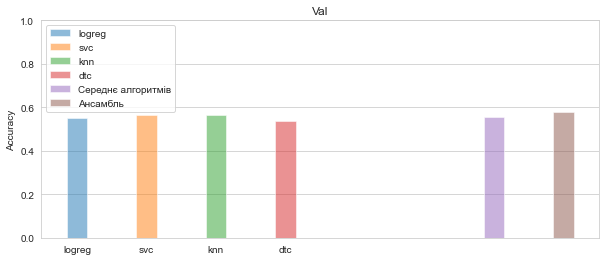

In [71]:
compare(pipeline)

Скор ансамблю знову кращий, ніж окремих алгоритмів.

##### Висновок.

Найкращою моделлю була `StackingClassifier` з скейлингом, підібраними параметрами для базових алгоритмів і фінальною моделлю `LogisticRegression` .

### Зробити висновки і обрати найкращу модель яка розв'язує задачу класифікації. Для найкращої моделі знайти прогнози на вибірці `wine_predict.csv`. Значення прогнозів зберегти у файл `predictions_clf.csv` використовуючи код з ноутбуку, що додається.




Загалом всі використані моделі показували себе на подібному рівні. Найкращими за результатами на крос-валідації були моделі `GradientBoostRegressor` i `StackingRegressor`. Зробимо фінальні прогнози.

In [72]:
predict = pd.read_csv("wine_predict.csv")
pipeline.fit(X_train, y_train)
y_final = pipeline.predict(predict)

In [73]:
# Зберегти прогнози у змінну best_clf_model_predictions
best_clf_model_predictions = y_final

In [74]:
# Запустити для створення файлу
pd.Series(best_clf_model_predictions).to_csv('predictions_clf.csv')

### Завдання 3

[1 бал]

Зберегти результати роботи у jupyter-ноутбук. Ноутбук повинен бути збережений у стані в якому усі клітинки запущені і не містити помилок. Формат назви файлу `M2_Прізвище_Ім'я.ipynb`

Окремо додати файл `predictions_clf.csv`.


Додатково можна отримати до [4 балів] за порівняннями результатів найкращих моделей завдання 2.